# Project 4
## Client: Risk Averse, LLC
### States Analyzed: Iowa and Oklahoma
### Custom Risk Definition: Wildfire Risk + Tornado Risk

## Section 1: Import Packages and Load Data

In [1]:
# Import all necessary packages for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
# Load the NRI Data Dictionary - this file explains all variable names in the NRI dataset
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

# Load NRI Census Tract data for Iowa
ia_nri = pd.read_csv("NRI_Table_CensusTracts_Iowa.csv")

# Load SVI data for Iowa
ia_svi = pd.read_csv("Iowa.csv")

# Load NRI Census Tract data for Oklahoma
ok_nri = pd.read_csv("NRI_Table_CensusTracts_Oklahoma.csv")

# Load SVI data for Oklahoma
ok_svi = pd.read_csv("Oklahoma.csv")

In [3]:
# Convert STATE to string so filtering by state name works reliably
ia_nri['STATE'] = ia_nri['STATE'].astype(str)
ok_nri['STATE'] = ok_nri['STATE'].astype(str)

print("Iowa STATE column confirmed in raw NRI:", 'STATE' in ia_nri.columns)
print("Oklahoma STATE column confirmed in raw NRI:", 'STATE' in ok_nri.columns)

Iowa STATE column confirmed in raw NRI: True
Oklahoma STATE column confirmed in raw NRI: True


In [4]:
# Preview the Iowa NRI data to confirm it loaded correctly
print("Iowa NRI shape:", ia_nri.shape)
ia_nri.head()

Iowa NRI shape: (896, 467)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,29850,T19001960100,Iowa,IA,19,Adair,County,1,19001,960100,...,97.253212,Relatively High,0.000025,2.721530e-07,0.000002,95.475257,38400.296430,96.903392,Relatively High,March 2023
1,29851,T19001960200,Iowa,IA,19,Adair,County,1,19001,960200,...,95.896846,Relatively High,0.000025,2.721530e-07,0.000002,95.518707,22311.637748,93.925700,Relatively High,March 2023
2,29852,T19001960300,Iowa,IA,19,Adair,County,1,19001,960300,...,96.492238,Relatively High,0.000025,2.721530e-07,0.000002,95.394227,31483.696562,95.974647,Relatively High,March 2023
3,29853,T19003950100,Iowa,IA,19,Adams,County,3,19003,950100,...,97.893229,Very High,0.000057,2.530546e-07,0.000002,98.333607,38204.563167,96.884365,Relatively High,March 2023
4,29854,T19003950200,Iowa,IA,19,Adams,County,3,19003,950200,...,98.405242,Very High,0.000057,2.530546e-07,0.000002,98.409940,56802.352720,98.205537,Very High,March 2023


In [5]:
# Preview the Oklahoma NRI data to confirm it loaded correctly
print("Oklahoma NRI shape:", ok_nri.shape)
ok_nri.head()

Oklahoma NRI shape: (77, 465)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,2133,C40001,Oklahoma,OK,40,Adair,County,1,40001,19445,...,80.656144,Relatively Moderate,0.000060,6.631220e-08,0.000069,88.765088,300713.18540,86.127903,Relatively High,Mar-23
1,2134,C40003,Oklahoma,OK,40,Alfalfa,County,3,40003,5699,...,24.574435,Relatively Low,0.000005,1.570770e-08,0.000067,77.158774,17000.53534,21.317213,Very Low,Mar-23
2,2135,C40005,Oklahoma,OK,40,Atoka,County,5,40005,14119,...,30.300217,Relatively Low,0.000007,3.315610e-08,0.000035,53.079542,30675.23004,33.789373,Relatively Low,Mar-23
3,2136,C40007,Oklahoma,OK,40,Beaver,County,7,40007,5045,...,53.946147,Relatively Moderate,0.000042,1.348860e-07,0.000012,84.586815,66053.47953,52.338530,Relatively Low,Mar-23
4,2137,C40009,Oklahoma,OK,40,Beckham,County,9,40009,22355,...,83.410709,Relatively High,0.000002,7.925770e-07,0.000064,90.931600,317875.87880,86.732421,Relatively High,Mar-23


In [6]:
# Preview the NRI data dictionary to understand what the column names mean
print("NRI Dictionary shape:", nri_dictionary.shape)
nri_dictionary.head(10)

NRI Dictionary shape: (479, 9)


,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
0,1,OBJECTID,OBJECTID,Integer,4.0,NaN,NaN,1.19.0,March 2023
1,2,Shape,Shape,Geometry,NaN,NaN,NaN,1.19.0,March 2023
2,3,Shape_Length,Shape_Length,Double,8.0,NaN,NaN,1.19.0,March 2023
3,4,Shape_Area,Shape_Area,Double,8.0,NaN,NaN,1.19.0,March 2023
4,5,STATE,State Name,String,250.0,All,NaN,1.19.0,March 2023
5,6,STATEABBRV,State Name Abbreviation,String,20.0,All,NaN,1.19.0,March 2023
6,7,STATEFIPS,State FIPS Code,String,20.0,All,NaN,1.19.0,March 2023
7,8,COUNTY,County Name,String,250.0,All,NaN,1.19.0,March 2023
8,9,COUNTYTYPE,County Type,String,250.0,All,NaN,1.19.0,March 2023
9,10,COUNTYFIPS,County FIPS Code,String,20.0,All,NaN,1.19.0,March 2023


In [7]:
# Check SVI column names to identify the shared key for merging
print("Iowa SVI columns:")
print(ia_svi.columns.tolist())
print("Oklahoma SVI columns:")
print(ok_svi.columns.tolist())

Iowa SVI columns:
['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', 'EP_GROUPQ', 'MP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', 'EPL_HBURD', 'EPL_NOHSDP', 'EPL_UNINSUR', '

## Section 2: Join Datasets for Iowa and Oklahoma

We merge the NRI data with the SVI data using a shared key column. The NRI dataset uses STCOFIPS and the SVI dataset uses STCNTY. We create a matching column in the NRI data before merging.

In [8]:
# Convert tract FIPS columns to string format and preserve leading zeros

# Replace -9999 with NaN - this is the standard NRI null placeholder value
ia_nri = ia_nri.replace(-9999, np.nan)
ok_nri = ok_nri.replace(-9999, np.nan)

# Extract tract FIPS from NRI_ID by removing the leading letter (T for tract, C for county)
# str[1:] takes everything after the first character
ia_nri['TRACTFIPS'] = ia_nri['NRI_ID'].astype(str).str[1:]
ok_nri['TRACTFIPS'] = ok_nri['NRI_ID'].astype(str).str[1:]

# Ensure SVI FIPS is string format so it matches the TRACTFIPS column
ia_svi['FIPS'] = ia_svi['FIPS'].astype(str)
ok_svi['FIPS'] = ok_svi['FIPS'].astype(str)


# Merge the Iowa NRI and SVI dataframes using tract FIPS as the shared key
ia_complete = pd.merge(ia_nri, 
                       ia_svi,
                       left_on='TRACTFIPS',
                       right_on='FIPS',
                       how='left')

# Merge the Oklahoma NRI and SVI dataframes using tract FIPS as the shared key
ok_complete = pd.merge(ok_nri,
                       ok_svi,
                       left_on='STCOFIPS',
                       right_on='STCNTY',
                       how='left')
print("Iowa merged rows:", len(ia_complete))
print("Oklahoma merged rows:", len(ok_complete))

Iowa merged rows: 896
Oklahoma merged rows: 1205


## Section 3: Handling Missing (NA) Values

Before performing any calculations, we need to identify and handle missing values in the dataset.

In [9]:
# Check how many NA values exist in the Iowa NRI data
print("Iowa NRI - NA counts per column (only columns with NAs shown):")
ia_na_counts = ia_nri.isna().sum()
print(ia_na_counts[ia_na_counts > 0])

Iowa NRI - NA counts per column (only columns with NAs shown):
AVLN_EVNTS        896
AVLN_AFREQ        896
AVLN_EXP_AREA     896
AVLN_EXPB         896
AVLN_EXPP         896
                 ... 
VLCN_ALRP         896
VLCN_ALR_NPCTL    896
VLCN_RISKV        896
VLCN_RISKS        896
WFIR_EVNTS        896
Length: 101, dtype: int64


In [10]:
# Check how many NA values exist in the Oklahoma NRI data
print("Oklahoma NRI - NA counts per column (only columns with NAs shown):")
ok_na_counts = ok_nri.isna().sum()
print(ok_na_counts[ok_na_counts > 0])

Oklahoma NRI - NA counts per column (only columns with NAs shown):
AVLN_EVNTS        77
AVLN_AFREQ        77
AVLN_EXP_AREA     77
AVLN_EXPB         77
AVLN_EXPP         77
                  ..
VLCN_ALRP         77
VLCN_ALR_NPCTL    77
VLCN_RISKV        77
VLCN_RISKS        77
WFIR_EVNTS        77
Length: 101, dtype: int64


In [11]:
# Option 1: Drop all rows that contain at least one NA value
# Note: This is too aggressive - dropping all rows removes the entire dataset
# ia_nri_dropped = ia_nri.dropna()
# print("Iowa rows after dropna():", ia_nri_dropped.shape[0], "(original:", ia_nri.shape[0], ")")

In [12]:
# Option 2: Drop all columns that contain at least one NA value
# Note: This removes many important hazard columns so it is not appropriate for this analysis
# ia_nri_dropped_columns = ia_nri.dropna(axis=1)
# print("Iowa columns after dropna(axis=1):", ia_nri_dropped_columns.shape[1]

In [13]:
# Option 3: Fill NA values with 0
# We use this approach to preserve all census tracts for analysis
# and assume missing hazard values indicate no recorded exposure in the dataset

ia_clean = ia_complete.copy()
ok_clean = ok_complete.copy()

# Option 3: Fill NA values with 0 for numeric columns only
ia_clean = ia_complete.copy()
ok_clean = ok_complete.copy()

# Use if statements to preserve STATE and COUNTY if they were renamed during merge
if 'STATE_x' in ia_clean.columns:
    ia_clean['STATE'] = ia_clean['STATE_x']
if 'STATE_x' in ok_clean.columns:
    ok_clean['STATE'] = ok_clean['STATE_x']

if 'COUNTY_x' in ia_clean.columns:
    ia_clean['COUNTY'] = ia_clean['COUNTY_x']
if 'COUNTY_x' in ok_clean.columns:
    ok_clean['COUNTY'] = ok_clean['COUNTY_x']

In [14]:
# Identify numeric columns only
num_cols_ia = ia_clean.select_dtypes(include=[np.number]).columns
num_cols_ok = ok_clean.select_dtypes(include=[np.number]).columns
# Fill NA only in numeric columns
ia_clean[num_cols_ia] = ia_clean[num_cols_ia].fillna(0)
ok_clean[num_cols_ok] = ok_clean[num_cols_ok].fillna(0)

print("Iowa filled with 0 - remaining NAs:", ia_clean.isna().sum().sum())
print("Oklahoma filled with 0 - remaining NAs:", ok_clean.isna().sum().sum())

Iowa filled with 0 - remaining NAs: 0
Oklahoma filled with 0 - remaining NAs: 0


## Section 4: Data Type Conversions

Checking and converting data types ensures calculations run correctly.

In [15]:
# Convert STATE to string type in both cleaned datasets
ia_clean['STATE'] = ia_clean['STATE'].astype(str)
ok_clean['STATE'] = ok_clean['STATE'].astype(str)

In [16]:
# Convert key identifier columns to string since they are labels, not values to calculate with
ia_clean['OID_'] = ia_clean['OID_'].astype(str)
ok_clean['OID_'] = ok_clean['OID_'].astype(str)

ia_clean['NRI_ID'] = ia_clean['NRI_ID'].astype(str)
ok_clean['NRI_ID'] = ok_clean['NRI_ID'].astype(str)

# str[1:] removes the leading letter from NRI_ID for both states
# Iowa IDs start with T (T19001960100)
ia_clean['TRACTFIPS'] = ia_clean['NRI_ID'].str[1:]
# Oklahoma TRACTFIPS comes from the SVI FIPS column which has the 11-digit tract FIPS
# We use this so Oklahoma tracts can be matched to the shapefile for mapping
ok_clean['TRACTFIPS'] = ok_clean['FIPS'].astype(str)

In [17]:
print("Iowa STATE type after conversion:", ia_clean['STATE'].dtype)
print("Iowa OID_ type after conversion:", ia_clean['OID_'].dtype)
print("Iowa TRACTFIPS:", ia_clean['TRACTFIPS'].head(3).tolist())
print("Oklahoma TRACTFIPS:", ok_clean['TRACTFIPS'].head(3).tolist())

Iowa STATE type after conversion: object
Iowa OID_ type after conversion: object
Iowa TRACTFIPS: ['19001960100', '19001960200', '19001960300']
Oklahoma TRACTFIPS: ['40001376600', '40001376700', '40001376800']


## Section 5: Create Custom Risk Columns

Our proposed risk definition is based on the classical formula: Risk = Probability x Impact

- Wildfire Risk = WFIR_AFREQ (Annual Frequency) x WFIR_EALT (Expected Annual Loss Total)
- Tornado Risk = TRND_AFREQ (Annual Frequency) x TRND_EALT (Expected Annual Loss Total)
- Combined Custom Risk Score = Wildfire Risk + Tornado Risk

In [18]:
# Iowa custom risk calculations
ia_clean['wildfire_risk'] = ia_clean['WFIR_AFREQ'] * ia_clean['WFIR_EALT']
ia_clean['tornado_risk'] = ia_clean['TRND_AFREQ'] * ia_clean['TRND_EALT']
ia_clean['custom_risk_score'] = ia_clean['wildfire_risk'] + ia_clean['tornado_risk']
print(ia_clean[['COUNTY', 
                'WFIR_AFREQ', 
                'WFIR_EALT',
                'wildfire_risk',
                'TRND_AFREQ', 
                'TRND_EALT',
                'tornado_risk', 
                'custom_risk_score']].head(10))

      COUNTY  WFIR_AFREQ    WFIR_EALT  wildfire_risk  TRND_AFREQ  \
0      Adair    0.000075  1555.422754       0.116190    0.252966   
1      Adair    0.000137  2342.611944       0.320251    0.238524   
2      Adair    0.000068   567.858380       0.038349    0.035884   
3      Adams    0.000184  5008.902480       0.919454    0.277795   
4      Adams    0.000202  7000.818872       1.415763    0.064809   
5  Allamakee    0.000018  1375.602114       0.024770    0.073525   
6  Allamakee    0.000016  2027.409581       0.032884    0.123112   
7  Allamakee    0.000011   834.750350       0.009136    0.006849   
8  Allamakee    0.000015  1890.727188       0.028352    0.112320   
9  Allamakee    0.000010  1561.987552       0.015803    0.067234   

       TRND_EALT   tornado_risk  custom_risk_score  
0  571318.030651  144524.016067      144524.132256  
1  405480.464352   96716.695571       96717.015823  
2  512227.830351   18380.942300       18380.980650  
3  337187.859423   93669.037884       9

C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\2801537360.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ia_clean['wildfire_risk'] = ia_clean['WFIR_AFREQ'] * ia_clean['WFIR_EALT']
C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\2801537360.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ia_clean['tornado_risk'] = ia_clean['TRND_AFREQ'] * ia_clean['TRND_EALT']
C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\2801537360.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [19]:
# Oklahoma custom risk calculations (same structure as Iowa)
ok_clean['wildfire_risk'] = ok_clean['WFIR_AFREQ'] * ok_clean['WFIR_EALT']
ok_clean['tornado_risk'] = ok_clean['TRND_AFREQ'] * ok_clean['TRND_EALT']
ok_clean['custom_risk_score'] = ok_clean['wildfire_risk'] + ok_clean['tornado_risk']

print(ok_clean[['COUNTY',
                'WFIR_AFREQ',
                'WFIR_EALT',
                'wildfire_risk',
                'TRND_AFREQ',
                'TRND_EALT',
                'tornado_risk',
                'custom_risk_score']].head(10))

    COUNTY  WFIR_AFREQ     WFIR_EALT  wildfire_risk  TRND_AFREQ     TRND_EALT  \
0    Adair    0.012121  2.007978e+06   24337.988045    0.567333  1.340902e+06   
1    Adair    0.012121  2.007978e+06   24337.988045    0.567333  1.340902e+06   
2    Adair    0.012121  2.007978e+06   24337.988045    0.567333  1.340902e+06   
3    Adair    0.012121  2.007978e+06   24337.988045    0.567333  1.340902e+06   
4    Adair    0.012121  2.007978e+06   24337.988045    0.567333  1.340902e+06   
5  Alfalfa    0.000062  4.940815e+03       0.306596    1.109461  7.309247e+05   
6  Alfalfa    0.000062  4.940815e+03       0.306596    1.109461  7.309247e+05   
7  Alfalfa    0.000062  4.940815e+03       0.306596    1.109461  7.309247e+05   
8    Atoka    0.009754  9.942203e+05    9697.717105    0.737672  7.963151e+05   
9    Atoka    0.009754  9.942203e+05    9697.717105    0.737672  7.963151e+05   

    tornado_risk  custom_risk_score  
0  760737.959982      785075.948027  
1  760737.959982      785075.948

C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\1737493740.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ok_clean['wildfire_risk'] = ok_clean['WFIR_AFREQ'] * ok_clean['WFIR_EALT']
C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\1737493740.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ok_clean['tornado_risk'] = ok_clean['TRND_AFREQ'] * ok_clean['TRND_EALT']
C:\Users\nomor\AppData\Local\Temp\ipykernel_33408\1737493740.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [20]:
# Fix for Oklahoma hazard columns still containing NaN after the earlier fillna
# Apply fillna(0) directly to the four columns used in the risk calculation
ok_clean['WFIR_AFREQ'] = ok_clean['WFIR_AFREQ'].fillna(0)
ok_clean['WFIR_EALT'] = ok_clean['WFIR_EALT'].fillna(0)
ok_clean['TRND_AFREQ'] = ok_clean['TRND_AFREQ'].fillna(0)
ok_clean['TRND_EALT'] = ok_clean['TRND_EALT'].fillna(0)

# Recalculate Oklahoma custom risk now that NaN values are gone
ok_clean['wildfire_risk'] = ok_clean['WFIR_AFREQ'] * ok_clean['WFIR_EALT']
ok_clean['tornado_risk'] = ok_clean['TRND_AFREQ'] * ok_clean['TRND_EALT']
ok_clean['custom_risk_score'] = ok_clean['wildfire_risk'] + ok_clean['tornado_risk']

## Section 6: Summary Tables

We group data by county to summarize and compare the NRI risk score against our custom risk score.

In [21]:
# RISK_SCORE is the NRI composite risk score for each census tract
ia_summary = ia_clean.groupby('COUNTY').agg(
    mean_nri_risk=('RISK_SCORE', 'mean'),
    mean_wildfire_risk=('wildfire_risk', 'mean'),
    mean_tornado_risk=('tornado_risk', 'mean'),
    mean_custom_risk=('custom_risk_score', 'mean')).reset_index()

ia_summary = ia_summary.sort_values('mean_custom_risk', ascending=False)

print("Iowa Summary Table - Top 20 Counties by Custom Risk Score:")
print(ia_summary.head(20).to_string(index=False))

Iowa Summary Table - Top 20 Counties by Custom Risk Score:
    COUNTY  mean_nri_risk  mean_wildfire_risk  mean_tornado_risk  mean_custom_risk
   Guthrie      88.495537            0.382238      162818.344316     162818.726553
     Davis      90.702445            0.097491      107351.152440     107351.249931
      Lyon      77.256655            0.867259      100942.867384     100943.734644
    Shelby      76.142201            0.018820       93040.240620      93040.259440
  Franklin      83.708716            0.014273       92463.497105      92463.511378
     Adair      79.410645            0.158263       86540.551313      86540.709576
   Carroll      79.823487            0.012048       82559.281120      82559.293167
       Sac      83.705644            0.011562       81500.695542      81500.707104
   Calhoun      87.534189            0.010991       81038.770185      81038.781176
  Plymouth      63.043254           37.098317       77740.064976      77777.163293
    Greene      79.767100   

In [22]:
# Oklahoma county-level summary
ok_summary = ok_clean.groupby('COUNTY').agg(
    mean_nri_risk=('RISK_SCORE', 'mean'),
    mean_wildfire_risk=('wildfire_risk', 'mean'),
    mean_tornado_risk=('tornado_risk', 'mean'),
    mean_custom_risk=('custom_risk_score', 'mean')).reset_index()

ok_summary = ok_summary.sort_values('mean_custom_risk', ascending=False)

print("Oklahoma Summary Table - Top 20 Counties by Custom Risk Score:")
print(ok_summary.head(20).to_string(index=False))

Oklahoma Summary Table - Top 20 Counties by Custom Risk Score:
      COUNTY  mean_nri_risk  mean_wildfire_risk  mean_tornado_risk  mean_custom_risk
    Oklahoma      97.263761          604.991412       3.914128e+07      3.914188e+07
       Tulsa      96.627426        11087.002136       2.261833e+07      2.262941e+07
    Canadian      87.782374          225.950369       1.531582e+07      1.531605e+07
    Comanche      88.482342         7400.085920       1.041707e+07      1.042447e+07
       Osage      73.751193        20358.926035       1.039473e+07      1.041509e+07
       Grady      78.078269         3069.784410       1.036658e+07      1.036965e+07
Pottawatomie      85.905186         7668.929136       1.007798e+07      1.008565e+07
   Cleveland      90.486796         1340.146446       9.680510e+06      9.681850e+06
       Payne      77.919185         7115.777842       8.262200e+06      8.269316e+06
       Creek      83.741648        23228.130561       7.996942e+06      8.020170e+06
  

## Section 7: Summary Figures

Bar plots comparing NRI risk and our custom risk definition by county.

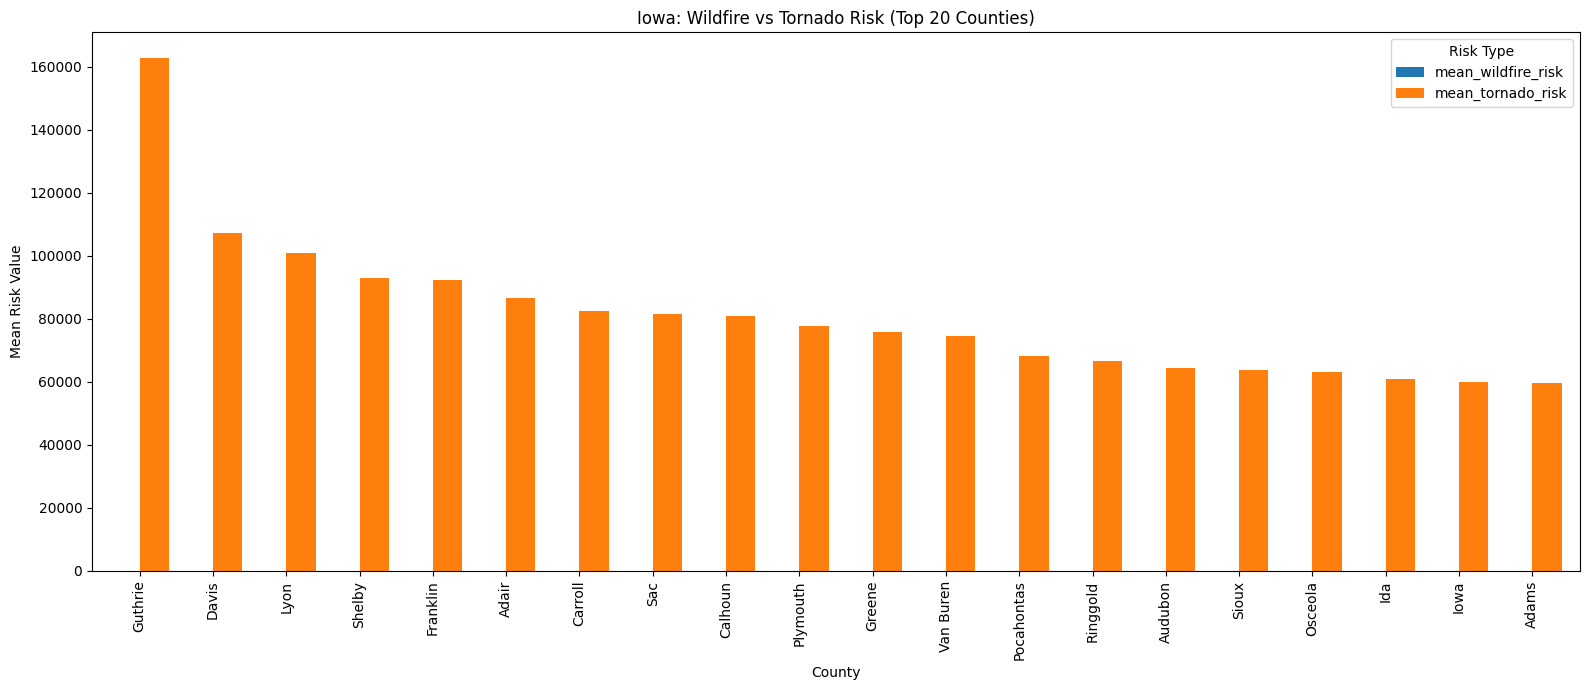

In [23]:
# Figure 1: Iowa - wildfire vs tornado risk by county (top 20)
ia_top20 = ia_summary.head(20).set_index('COUNTY')

ia_top20[['mean_wildfire_risk', 'mean_tornado_risk']].plot(kind='bar', figsize=(16, 7), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Iowa: Wildfire vs Tornado Risk (Top 20 Counties)')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

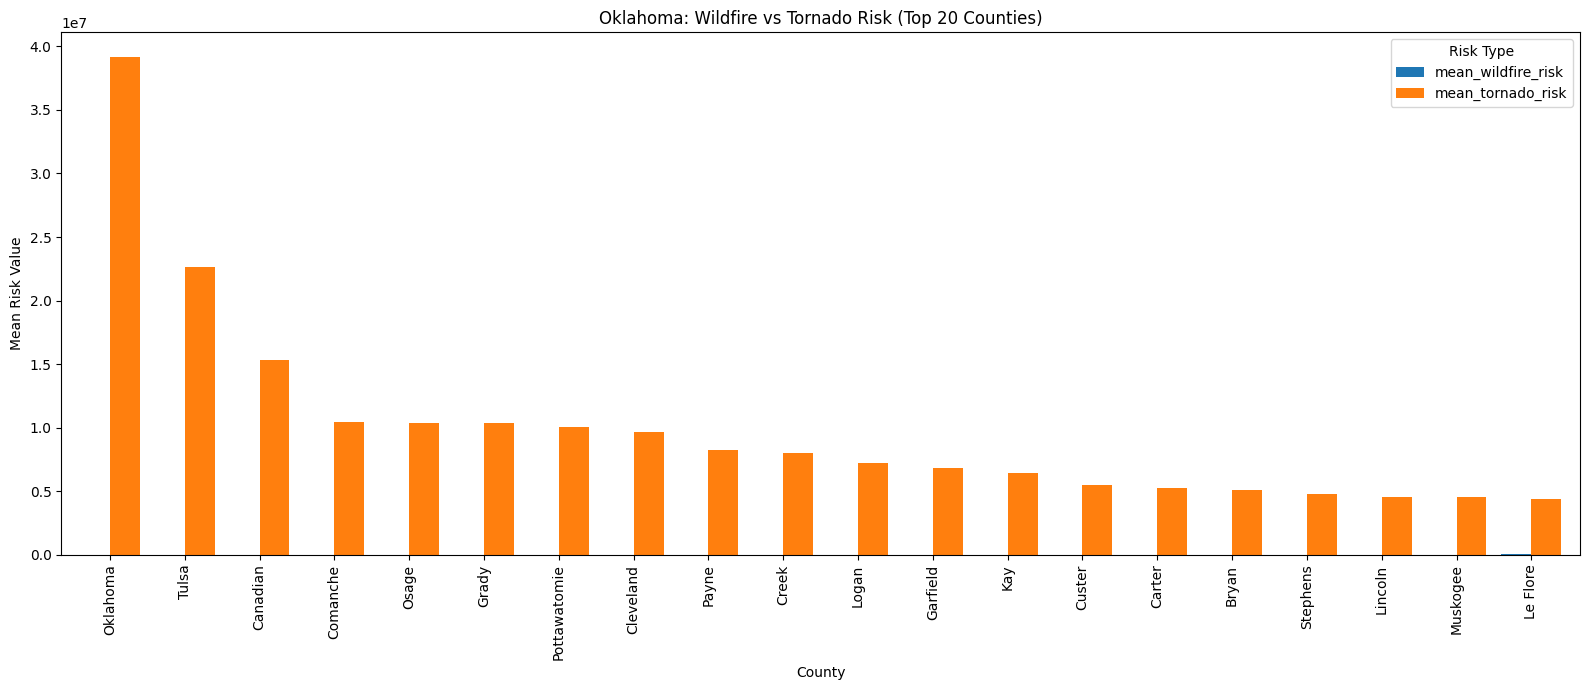

In [24]:
# Figure 2: Oklahoma - wildfire vs tornado risk by county (top 20)
ok_top20 = ok_summary.head(20).set_index('COUNTY')

ok_top20[['mean_wildfire_risk', 'mean_tornado_risk']].plot(kind='bar', figsize=(16, 7), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Oklahoma: Wildfire vs Tornado Risk (Top 20 Counties)')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

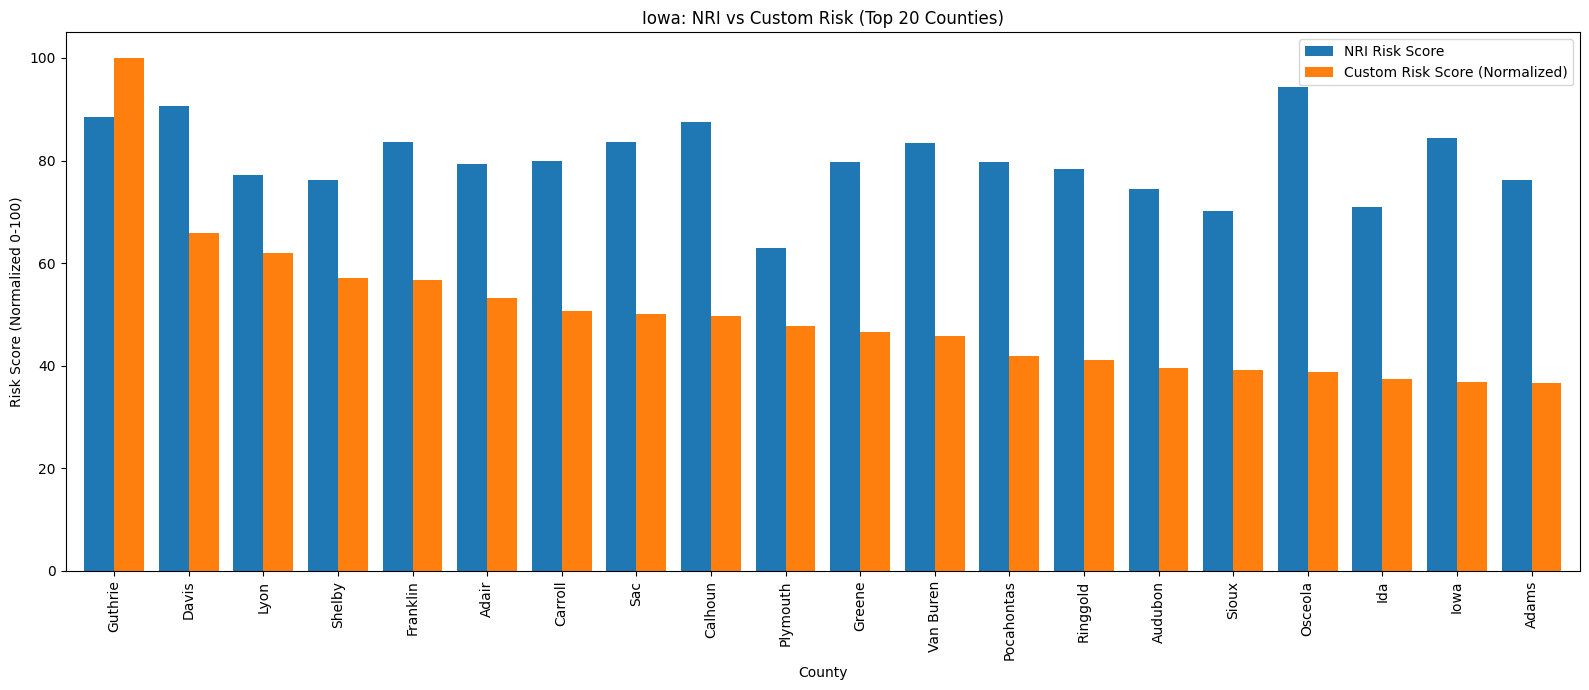

In [25]:
# Figure 3: Iowa - NRI vs Custom Risk comparison by county (top 20)
# Normalize custom risk to 0-100 so it can be visually compared to the NRI score
ia_top20_compare = ia_summary.head(20).set_index('COUNTY').copy()
ia_top20_compare['custom_risk_norm'] = (ia_top20_compare['mean_custom_risk'] / ia_top20_compare['mean_custom_risk'].max()) * 100

ia_top20_compare[['mean_nri_risk', 'custom_risk_norm']].plot(kind='bar', figsize=(16, 7), width=0.8)
plt.xlabel('County')
plt.ylabel('Risk Score (Normalized 0-100)')
plt.title('Iowa: NRI vs Custom Risk (Top 20 Counties)')
plt.xticks(rotation=90)
plt.legend(['NRI Risk Score', 'Custom Risk Score (Normalized)'])
plt.tight_layout()
plt.show()


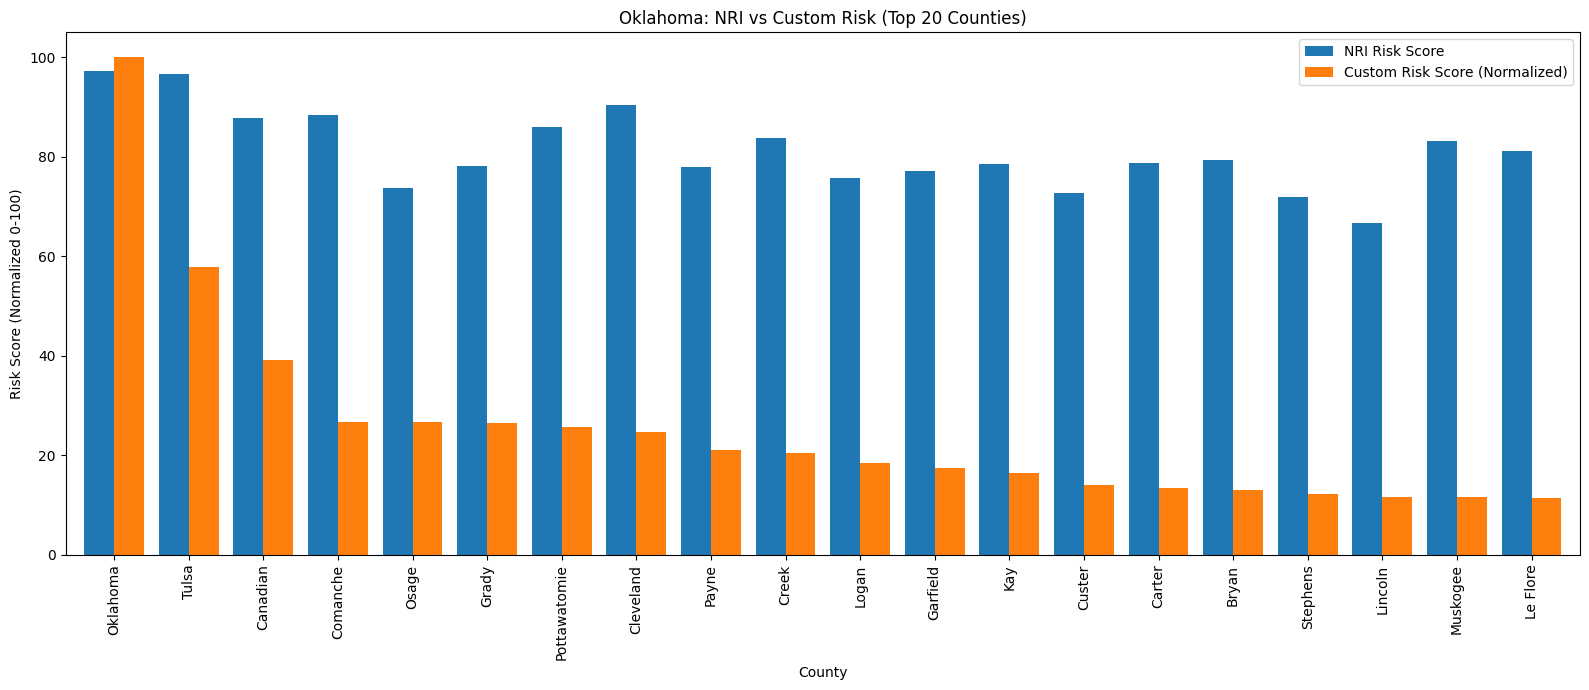

In [26]:
# Figure 4: Oklahoma - NRI vs Custom Risk comparison by county (top 20)
ok_top20_compare = ok_summary.head(20).set_index('COUNTY').copy()
ok_top20_compare['custom_risk_norm'] = (ok_top20_compare['mean_custom_risk'] / ok_top20_compare['mean_custom_risk'].max()) * 100

ok_top20_compare[['mean_nri_risk', 'custom_risk_norm']].plot(kind='bar', figsize=(16, 7), width=0.8)
plt.xlabel('County')
plt.ylabel('Risk Score (Normalized 0-100)')
plt.title('Oklahoma: NRI vs Custom Risk (Top 20 Counties)')
plt.xticks(rotation=90)
plt.legend(['NRI Risk Score', 'Custom Risk Score (Normalized)'])
plt.tight_layout()
plt.show()

## Section 8: GeoPandas Mapping

We use the NRI Shapefile at the Census Tract level to map risk values spatially.

In [27]:
# Load and clean the NRI Census Tract shapefile
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

tracts_clean = tracts.set_crs(epsg=3857, inplace=False, allow_override=True)
tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean = tracts_clean.replace(-9999, np.nan)

ia_map = tracts_clean[tracts_clean["STATE"] == "Iowa"].copy()
ok_map = tracts_clean[tracts_clean["STATE"] == "Oklahoma"].copy()

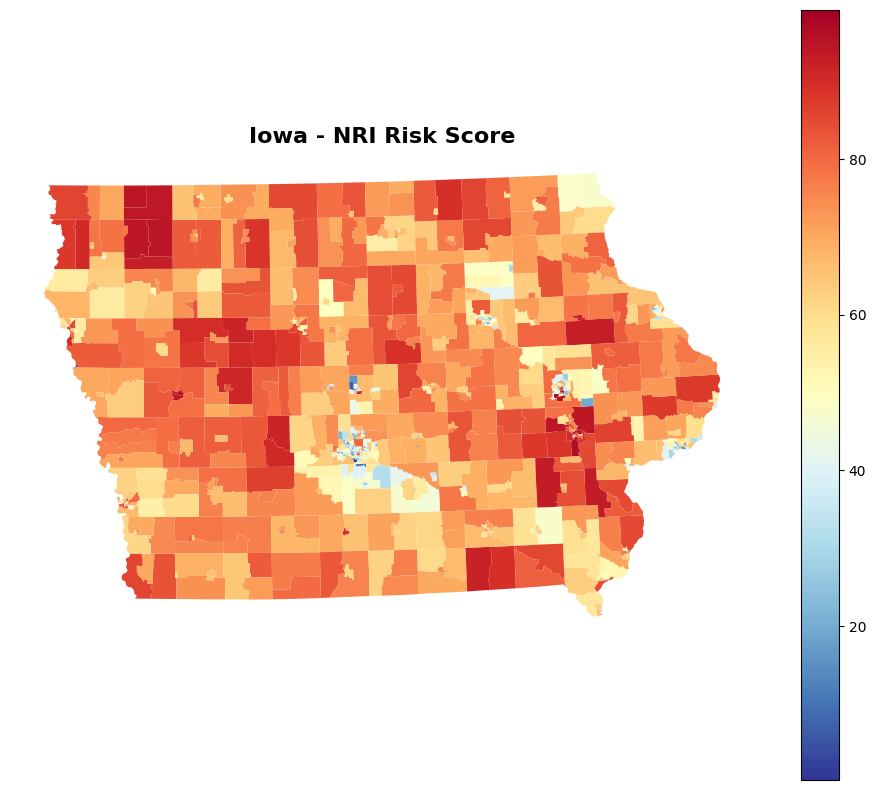

In [28]:
# Map 1: NRI Risk Score for Iowa
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ia_map.plot(column="RISK_SCORE", ax=ax, 
            legend=True,
            cmap="RdYlBu_r",
            linewidth=0,
            missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Iowa - NRI Risk Score", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.show()

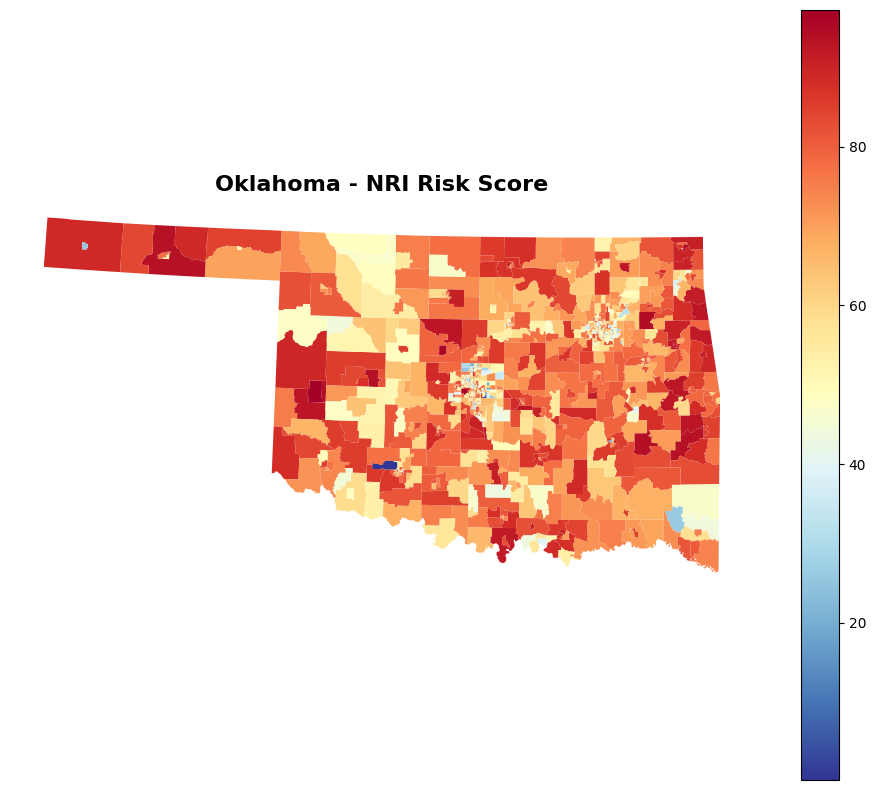

In [29]:
# Map 2: NRI Risk Score for Oklahoma
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ok_map.plot(column="RISK_SCORE", 
            ax=ax, 
            legend=True,
            cmap="RdYlBu_r", 
            linewidth=0,
            missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Oklahoma - NRI Risk Score", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.show()


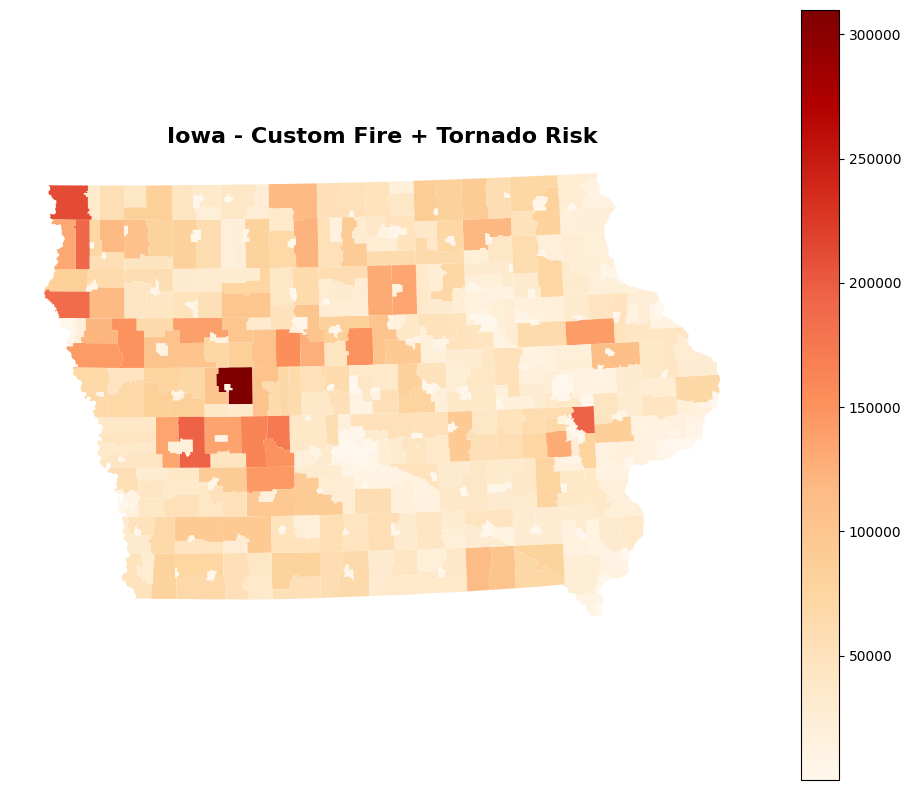

In [30]:
# Map 3: Custom Risk Score for Iowa
# Merge custom risk scores back into the Iowa shapefile using TRACTFIPS as the key
ia_geo = ia_map.merge(ia_clean[['TRACTFIPS', 'custom_risk_score']], on='TRACTFIPS', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ia_geo.plot(column="custom_risk_score", 
            ax=ax,
            legend=True,
            cmap="OrRd",
            linewidth=0,
            missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Iowa - Custom Fire + Tornado Risk", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.show()

Oklahoma missing matches: 0


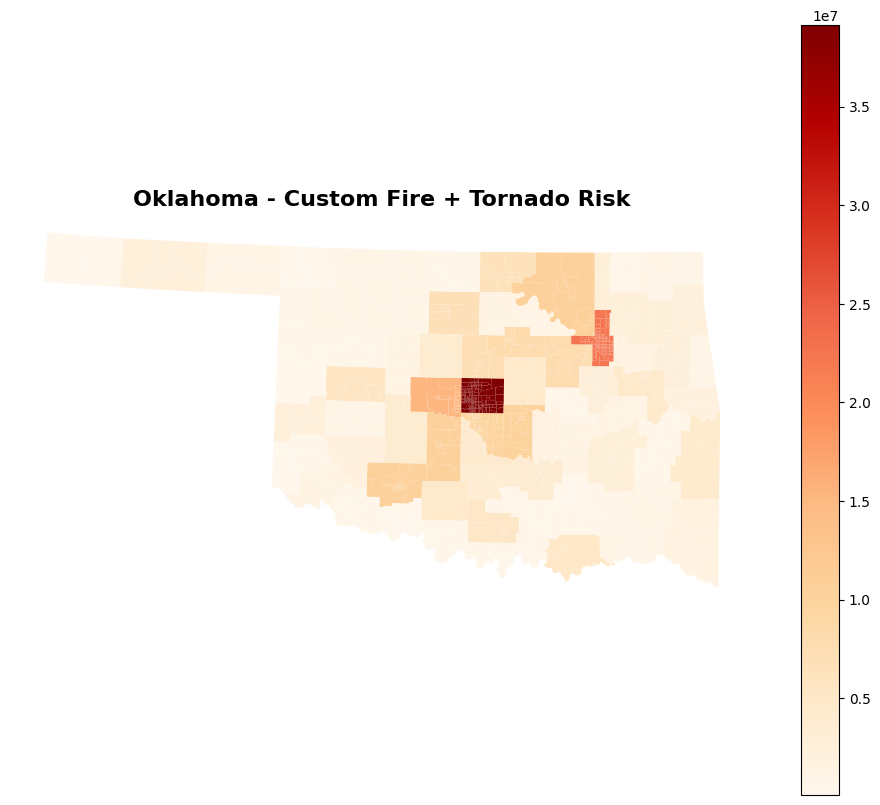

In [37]:
# Map 4: Custom Risk Score for Oklahoma
# Now that Oklahoma was merged at the tract level, we can map it the same way as Iowa
ok_geo = ok_map.merge(ok_clean[['TRACTFIPS', 'custom_risk_score']], on='TRACTFIPS', how='left')

print("Oklahoma missing matches:", ok_geo['custom_risk_score'].isna().sum())

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ok_geo.plot(column="custom_risk_score",
            ax=ax, legend=True,
            cmap="OrRd",
            linewidth=0,
            missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Oklahoma - Custom Fire + Tornado Risk", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.show()

## Section 9: Summary Statistics Comparison

Final summary statistics comparing NRI risk scores with our custom risk scores for both states.

In [38]:
# Descriptive statistics for Iowa
print("=== Iowa Summary Statistics ===")
print("NRI Risk Score:")
print(ia_clean['RISK_VALUE'].describe())
print("Custom Risk Score (Wildfire + Tornado):")
print(ia_clean['custom_risk_score'].describe())
print("Wildfire Risk:")
print(ia_clean['wildfire_risk'].describe())
print("Tornado Risk:")
print(ia_clean['tornado_risk'].describe())

=== Iowa Summary Statistics ===
NRI Risk Score:
count    8.960000e+02
mean     9.412124e+05
std      6.869263e+05
min      9.262296e+03
25%      5.072315e+05
50%      8.096101e+05
75%      1.166488e+06
max      8.180885e+06
Name: RISK_VALUE, dtype: float64
Custom Risk Score (Wildfire + Tornado):
count       896.000000
mean      21614.464864
std       35446.568711
min           6.057095
25%         566.811906
50%        2744.396698
75%       32719.816634
max      309822.011100
Name: custom_risk_score, dtype: float64
Wildfire Risk:
count    896.000000
mean       1.364388
std       10.633867
min        0.000000
25%        0.003545
50%        0.014546
75%        0.112424
max      219.794078
Name: wildfire_risk, dtype: float64
Tornado Risk:
count       896.000000
mean      21613.100476
std       35445.273433
min           5.744187
25%         566.811615
50%        2744.374889
75%       32719.730919
max      309821.984718
Name: tornado_risk, dtype: float64


In [39]:
# Descriptive statistics for Oklahoma
print("=== Oklahoma Summary Statistics ===")
print("NRI Risk Score:")
print(ok_clean['RISK_VALUE'].describe())
print("Custom Risk Score (Wildfire + Tornado):")
print(ok_clean['custom_risk_score'].describe())
print("Wildfire Risk:")
print(ok_clean['wildfire_risk'].describe())
print("Tornado Risk:")
print(ok_clean['tornado_risk'].describe())

=== Oklahoma Summary Statistics ===
NRI Risk Score:
count    1.205000e+03
mean     7.592475e+07
std      7.068352e+07
min      1.778714e+06
25%      1.612551e+07
50%      3.468729e+07
75%      1.451669e+08
max      1.752270e+08
Name: RISK_VALUE, dtype: float64
Custom Risk Score (Wildfire + Tornado):
count    1.205000e+03
mean     1.579990e+07
std      1.431124e+07
min      9.511898e+04
25%      2.971260e+06
50%      9.681850e+06
75%      2.262941e+07
max      3.914188e+07
Name: custom_risk_score, dtype: float64
Wildfire Risk:
count     1205.000000
mean      7514.053012
std      11992.885600
min          0.136446
25%        604.991412
50%       3351.951992
75%      11087.002136
max      68535.989683
Name: wildfire_risk, dtype: float64
Tornado Risk:
count    1.205000e+03
mean     1.579238e+07
std      1.431450e+07
min      9.444645e+04
25%      2.966320e+06
50%      9.680510e+06
75%      2.261833e+07
max      3.914128e+07
Name: tornado_risk, dtype: float64


In [40]:
# Figure 5: State-level comparison of NRI vs Custom Risk - Iowa vs Oklahoma
# Both scores are normalized to 0-100 so they can be compared on the same axis
ia_mean_custom = ia_clean['custom_risk_score'].mean()
ok_mean_custom = ok_clean['custom_risk_score'].mean()
ia_mean_nri = ia_clean['RISK_VALUE'].mean()
ok_mean_nri = ok_clean['RISK_VALUE'].mean()


In [41]:
# Print means first to confirm they are not NaN before plotting
print("Iowa mean custom:", ia_mean_custom)
print("Oklahoma mean custom:", ok_mean_custom)
print("Iowa mean NRI:", ia_mean_nri)
print("Oklahoma mean NRI:", ok_mean_nri)

Iowa mean custom: 21614.464863785743
Oklahoma mean custom: 15799898.58920776
Iowa mean NRI: 941212.3844138617
Oklahoma mean NRI: 75924751.96102738


   State  NRI Risk Score (Normalized)  Custom Risk Score (Normalized)
    Iowa                     1.239665                        0.136801
Oklahoma                   100.000000                      100.000000


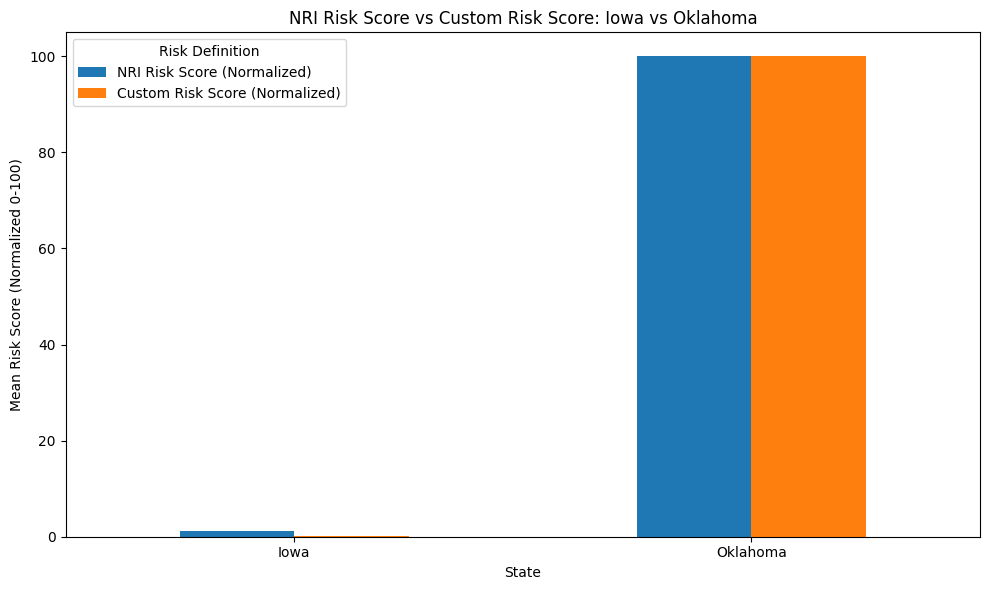

In [42]:
custom_scale = max(ia_mean_custom, ok_mean_custom)
nri_scale = max(ia_mean_nri, ok_mean_nri)

state_comparison = pd.DataFrame({
    'State': ['Iowa', 'Oklahoma'],
    'NRI Risk Score (Normalized)': [(ia_mean_nri / nri_scale) * 100, 
                                    (ok_mean_nri / nri_scale) * 100],
    'Custom Risk Score (Normalized)': [(ia_mean_custom / custom_scale) * 100,
                                       (ok_mean_custom / custom_scale) * 100]})

print(state_comparison.to_string(index=False))

state_comparison.set_index('State').plot(kind='bar', figsize=(10, 6), width=0.5)
plt.xlabel('State')
plt.ylabel('Mean Risk Score (Normalized 0-100)')
plt.title('NRI Risk Score vs Custom Risk Score: Iowa vs Oklahoma')
plt.xticks(rotation=0)
plt.legend(title='Risk Definition')
plt.tight_layout()
plt.show()